## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [8]:
df = pd.read_csv('../Data/imbalanced_data.csv')
df

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [9]:
df.sample(10)

,id,label,tweet
5399,5400,0,recite this dua as u can.. #ramazan #dua
4781,4782,0,father's day to the most amazing. dad love y...
2123,2124,0,"seriously, when i saw #orlandoshooting on tv, ..."
8734,8735,0,#prideweek it's jelly donut time guuurrrlll
19368,19369,1,"@user #allahsoil like all religions, islam can..."
23796,23797,0,a lot of commercials about bullying during thi...
23141,23142,0,@user @user it saddens me to know these weapon...
4671,4672,0,pickle ball time!
2434,2435,0,i'm fine. teens poems ness quotes #hu #alone...
25002,25003,0,@user my photo from @user 's #greatbarrierree...


In [10]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [11]:
df.tail()

,id,label,tweet
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."
31961,31962,0,thank you @user for you follow


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [13]:
# Check Missing Values
df.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

In [14]:
# Check Duplicate Values
df.duplicated().sum()

0

In [ ]:
# Target Column Distribution

df['label'].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

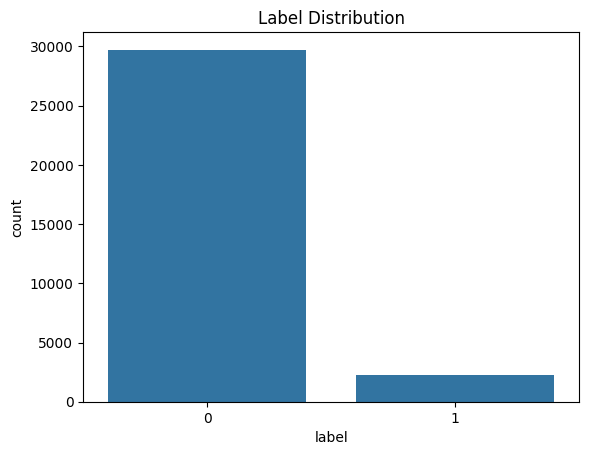

In [16]:
sns.countplot(x=df['label'])
plt.title('Label Distribution')
plt.show()

In [ ]:
# Add Tweet Length Column

df['tweet_length'] = df['tweet'].apply(len)

In [18]:
df[['tweet', 'tweet_length']].head()

,tweet,tweet_length
0,@user when a father is dysfunctional and is s...,102
1,@user @user thanks for #lyft credit i can't us...,122
2,bihday your majesty,21
3,#model i love u take with u all the time in ...,86
4,factsguide: society now #motivation,39


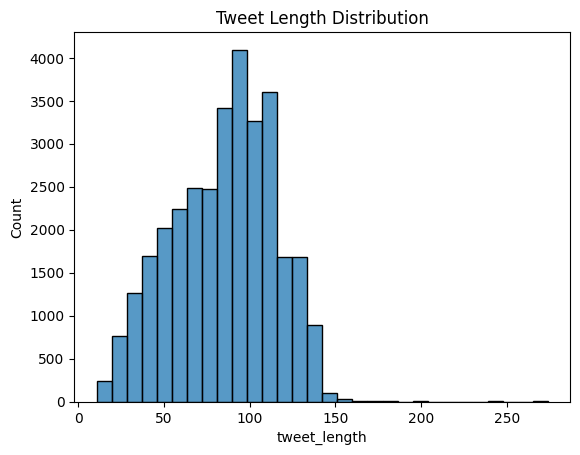

In [ ]:
# Plot Tweet Length

plt.figure()
sns.histplot(df['tweet_length'], bins=30)
plt.title('Tweet Length Distribution')
plt.show()

In [21]:
# Word Count

df['word_count'] = df['tweet'].apply(lambda x: len(str(x).split()))

In [22]:
df[['tweet', 'word_count']].head()

,tweet,word_count
0,@user when a father is dysfunctional and is s...,18
1,@user @user thanks for #lyft credit i can't us...,19
2,bihday your majesty,3
3,#model i love u take with u all the time in ...,14
4,factsguide: society now #motivation,4


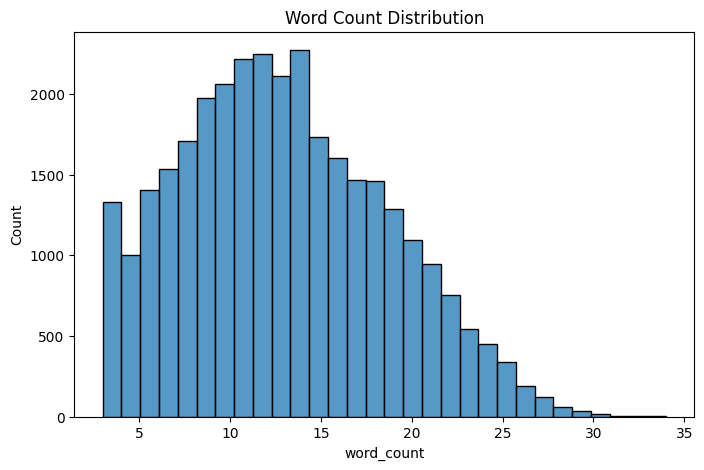

In [23]:
# Plot Word Count

plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=30)
plt.title('Word Count Distribution')
plt.show()

In [24]:
# Most Common Words

all_words = ' '.join(df['tweet'])
words = all_words.split()

In [25]:
from collections import Counter

common_words = Counter(words).most_common(10)
common_words

[('@user', 17291),
 ('the', 10065),
 ('to', 9768),
 ('a', 6261),
 ('i', 5655),
 ('you', 4949),
 ('and', 4831),
 ('in', 4570),
 ('for', 4435),
 ('of', 4152)]

In [26]:
words_df = pd.DataFrame(common_words, columns=['Word', 'Count'])
words_df

,Word,Count
0,@user,17291
1,the,10065
2,to,9768
3,a,6261
4,i,5655
5,you,4949
6,and,4831
7,in,4570
8,for,4435
9,of,4152


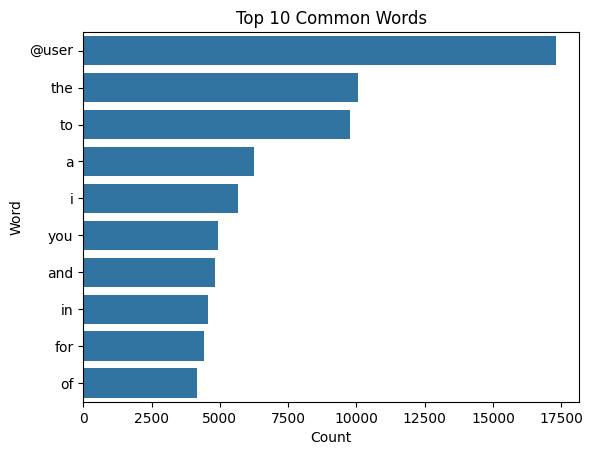

In [27]:
sns.barplot(x='Count', y='Word', data=words_df)
plt.title('Top 10 Common Words')
plt.show()